<a href="https://colab.research.google.com/github/Kei300/P2-IA-Python-Libraries-Statistics/blob/main/3_O3_uam_Iztapalapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#O3  horario UAM Iztapalapa

In [1]:
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

In [2]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning, ValueWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', category=InterpolationWarning)
warnings.simplefilter('ignore', category=ValueWarning)

In [3]:
df = pd.read_csv(
    '/content/contaminantes_2026.csv',
    header=9,
    on_bad_lines='skip',
    engine='python'
)

In [4]:
df_uiz_o3 = df[(df['id_parameter'] == 'O3') & (df['id_station'] == 'UIZ')].copy()

display(df_uiz_o3)

,date,id_station,id_parameter,valor,unit
283,2026-01-01 00:00:00,UIZ,O3,14.0,1
589,2026-01-01 01:00:00,UIZ,O3,5.0,1
895,2026-01-01 02:00:00,UIZ,O3,2.0,1
1201,2026-01-01 03:00:00,UIZ,O3,3.0,1
1507,2026-01-01 04:00:00,UIZ,O3,3.0,1
...,...,...,...,...,...
1555681,2026-07-31 19:00:00,UIZ,O3,35.0,1
1555987,2026-07-31 20:00:00,UIZ,O3,36.0,1
1556293,2026-07-31 21:00:00,UIZ,O3,33.0,1
1556599,2026-07-31 22:00:00,UIZ,O3,31.0,1


In [5]:
duplicated_rows = df_uiz_o3.duplicated().sum()
print(f"\n Filas duplicadas: {duplicated_rows}")


 Filas duplicadas: 0


In [6]:
df_uiz_o3 = df_uiz_o3.drop_duplicates()
valores = df_uiz_o3['valor']
df_uiz_o3['datetime'] = pd.to_datetime(df_uiz_o3['date'])
df_uiz_o3 = df_uiz_o3.set_index('datetime').sort_index()

a) Cuente los huecos y decida como tratarlos

In [7]:
huecos = (valores < 0) | (valores.isna())
print(f"Total de datos faltantes: {huecos.sum()} de {len(df_uiz_o3)} horas registradas")

Total de datos faltantes: 228 de 5088 horas registradas


In [8]:
# 1. Asegurar frecuencia horaria continua
df_uiz_o3 = df_uiz_o3.asfreq('h')
df_uiz_o3['valor'] = df_uiz_o3['valor'].apply(lambda x: np.nan if x < 0 else x)

# huecos pequeños (≤ 3 h) con Interpolación Lineal
df_uiz_o3['o3_imputado'] = df_uiz_o3['valor'].interpolate(method='linear', limit=3)

#  huecos restantes, Modelo Predictivo (MICE/Regresión)
df_uiz_o3['hora'] = df_uiz_o3.index.hour
df_uiz_o3['dia_semana'] = df_uiz_o3.index.dayofweek
df_uiz_o3['mes'] = df_uiz_o3.index.month

imputer = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=42)
matriz_predicha = imputer.fit_transform(df_uiz_o3[['o3_imputado', 'hora', 'dia_semana', 'mes']])

df_uiz_o3['o3_imputado'] = matriz_predicha[:, 0]

b) grafica de la serie con ACF, 72 horas

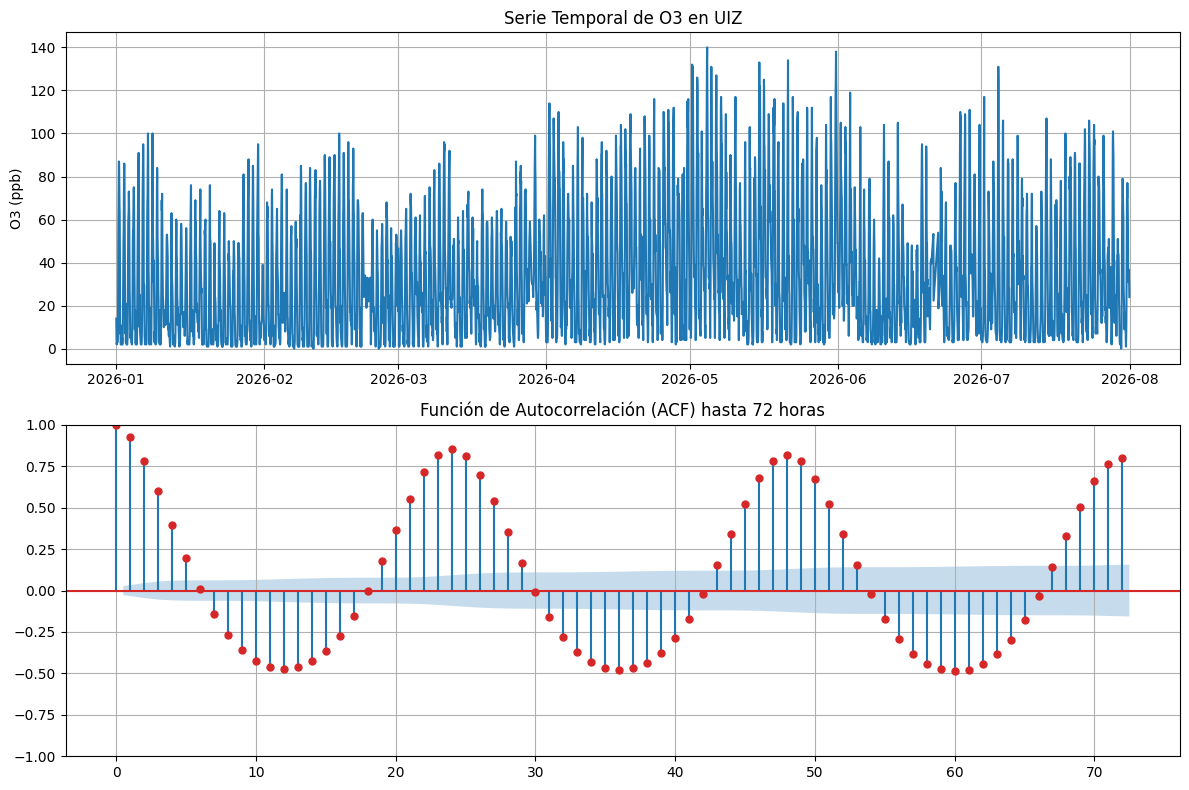

In [9]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df_uiz_o3.index, df_uiz_o3['o3_imputado'], color='tab:blue')
axes[0].set_title("Serie Temporal de O3 en UIZ")
axes[0].set_ylabel("O3 (ppb)")
axes[0].grid(True)

plot_acf(df_uiz_o3['o3_imputado'], lags=72, ax=axes[1], color='tab:red')
axes[1].set_title("Función de Autocorrelación (ACF) hasta 72 horas")
axes[1].grid(True)

plt.tight_layout()
plt.show()

c) ADF y KPSS

In [10]:
from statsmodels.tsa.stattools import adfuller

adf_stat, p_value, *_ = adfuller(df_uiz_o3['o3_imputado'].dropna(), autolag='AIC')

print(f"p-value: {p_value:.4f}")

p-value: 0.0000


In [11]:
from statsmodels.tsa.stattools import kpss

kpss_stat, p_value, *_ = kpss(df_uiz_o3['o3_imputado'].dropna(), regression='c', nlags='auto')

print(f"p-value: {p_value:.4f}")

p-value: 0.0100


d) Restar la media de cada hora del día

In [12]:
df_uiz_o3['res_hora'] = df_uiz_o3['o3_imputado'] - df_uiz_o3.groupby('hora')['o3_imputado'].transform('mean')

adf_d, p_adf_d, *_ = adfuller(df_uiz_o3['res_hora'].dropna(), autolag='AIC')
kpss_d, p_kpss_d, *_ = kpss(df_uiz_o3['res_hora'].dropna(), regression='c', nlags='auto')

print(f"ADF p-value:  {p_adf_d:.4f}")
print(f"KPSS p-value: {p_kpss_d:.4f}")

ADF p-value:  0.0000
KPSS p-value: 0.0100


e) Restar la media de cada mes × hora

In [13]:
df_uiz_o3['res_mes_hora'] = df_uiz_o3['o3_imputado'] - df_uiz_o3.groupby(['mes', 'hora'])['o3_imputado'].transform('mean')

adf_e, p_adf_e, *_ = adfuller(df_uiz_o3['res_mes_hora'].dropna(), autolag='AIC')
kpss_e, p_kpss_e, *_ = kpss(df_uiz_o3['res_mes_hora'].dropna(), regression='c', nlags='auto')

print(f"ADF p-value:  {p_adf_e:.4f}")
print(f"KPSS p-value: {p_kpss_e:.4f}")

ADF p-value:  0.0000
KPSS p-value: 0.1000


f) Diferencia de 24 h y comparación con (e)

In [14]:
# Diferencia estacional de 24 horas
df_uiz_o3['diff_24h'] = df_uiz_o3['o3_imputado'].diff(24)

In [15]:
# Varianzas
var_e = df_uiz_o3['res_mes_hora'].var()
var_f = df_uiz_o3['diff_24h'].var()

print(f"Varianza Inciso (e): {var_e:.4f}")
print(f"Varianza Inciso (f): {var_f:.4f}")

Varianza Inciso (e): 160.4706
Varianza Inciso (f): 239.9344


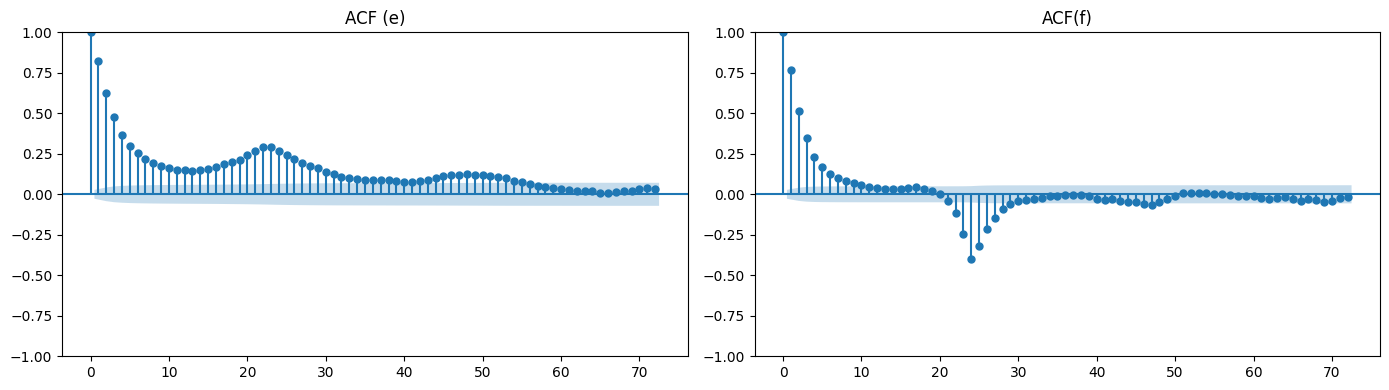

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_uiz_o3['res_mes_hora'].dropna(), lags=72, ax=axes[0], title="ACF (e)")
plot_acf(df_uiz_o3['diff_24h'].dropna(), lags=72, ax=axes[1], title="ACF(f)")
plt.tight_layout()
plt.show()

**La serie es estacionaria**

* Originalmente, según la prueba ADF la serie es estacionaria porque su $p\text{-value}$ es $< 0.05$ ($0.0000$), pero KPSS indica que NO es estacionaria debido a que su $p\text{-value}$ es $0.0100$ ($< 0.05$). Hay problemas con la varianza o presencia de estacionalidad fuerte en los datos (el ciclo diario del ozono).


* Al restar solo la media horaria del inciso d se vuelve a obtener exactamente lo mismo ($p\text{-values}$ de $0.0000$ y $0.0100$), ya que no limpia las variaciones entre meses. En cambio, al aplicar el inciso e (resta de media mes $\times$ hora), los valores de $p\text{-value}$ con ADF indican que es estacionaria debido a que se mantiene en $0.0000$ ($< 0.05$), y ahora KPSS da que SÍ es estacionaria debido a que su $p\text{-value}$ sube a $0.1000$ ($> 0.05$).   

* Se descarta el inciso f (diferencia de 24 h) debido a que, al comparar su varianza con la del inciso e, se observa que f incrementa la varianza a $239.93$ frente a $160.47$ de e, además de que genera un pico negativo en la gráfica de ACF.